# Aplicação — Conceito de Base no Método Simplex
## PPG-Biometria
### Disciplina: Matemática Aplicada
### Professor: Fernando Luiz Pio dos Santos
### Aluno: Vitor Eduardo Girotto Barelli

### Objetivo

1. Entender o Método Simplex a partir do conceitos de Álgebra Linear (base de espaços vetoriais);
2. Relacionar soluções básicas viáveis com vértices da região viável;
3. Resolver um exemplo manualmente;
4. Implementar o Método Simplex em Python;
5. Testar a implementação em diferentes exemplos.

OBS: Como informado em aula a principal referência a ser usada é o capítulo 2 (seção 2.6) do livro Pesquisa Operacional, de Arenales et al., especialmente a parte de teoria básica e método simplex e os exemplos numéricos do método.

## 1. O Método Simplex visto pela Álgebra Linear

Considere um problema de programação linear na forma padrão de minimização:

\[
\min f(x)=c^T x
\]

sujeito a:

\[
Ax=b, \qquad x\geq 0,
\]

em que:

- \(A\in\mathbb{R}^{m\times n}\), com \(m<n\);
- \(b\in\mathbb{R}^{m}\);
- \(c\in\mathbb{R}^{n}\);
- \(\operatorname{posto}(A)=m\).

Como \(A\) tem posto completo por linhas, podemos escolher \(m\) colunas linearmente independentes de \(A\). Essas colunas formam uma **matriz básica**:

\[
B = [a_{B_1},a_{B_2},\dots,a_{B_m}].
\]

As demais colunas formam a matriz não básica \(N\). Assim, após reorganização das colunas:

\[
A=[B\;N].
\]

O vetor de variáveis também é particionado:

\[
x=\begin{bmatrix}x_B\\x_N\end{bmatrix},
\]

onde:

- \(x_B\) contém as **variáveis básicas**;
- \(x_N\) contém as **variáveis não básicas**.

O sistema \(Ax=b\) pode ser escrito como:

\[
Bx_B+Nx_N=b.
\]

Como \(B\) é inversível:

\[
x_B=B^{-1}b-B^{-1}Nx_N.
\]

A **solução básica** associada à base \(B\) é obtida fixando as variáveis não básicas em zero:

\[
\hat{x}_N=0,
\]

\[
\hat{x}_B=B^{-1}b.
\]

Se \(\hat{x}_B\geq 0\), então a solução básica é uma **solução básica viável**.

Portanto, o Simplex é, em essência, um algoritmo que caminha entre bases. Em cada iteração, uma coluna entra na base e outra coluna sai da base.

### 1.1 Custos relativos e condição de otimalidade

Para uma base \(B\), a função objetivo pode ser analisada localmente pelas variáveis não básicas. Definimos o vetor multiplicador simplex \(\lambda\) por:

\[
B^T\lambda=c_B.
\]

Equivalentemente:

\[
\lambda^T=c_B^T B^{-1}.
\]

Para cada variável não básica \(x_j\), o **custo relativo** é:

\[
\bar{c}_j=c_j-\lambda^T a_j.
\]

Em um problema de **minimização**:

- se todos os custos relativos são não negativos, isto é,

\[
\bar{c}_j\geq 0,
\]

então a solução básica viável atual é ótima;

- se existe \(\bar{c}_j<0\), aumentar essa variável não básica pode reduzir o valor da função objetivo.

A variável com custo relativo negativo é candidata a **entrar na base**.

### 1.2 Direção simplex e tamanho do passo

Suponha que a variável não básica \(x_k\) entre na base. A direção associada é:

\[
y=B^{-1}a_k.
\]

Ao aumentar \(x_k\) de zero para \(\varepsilon\), as variáveis básicas mudam conforme:

\[
x_B(\varepsilon)=\hat{x}_B-y\varepsilon.
\]

Para manter a viabilidade, precisamos de:

\[
\hat{x}_{B_i}-y_i\varepsilon\geq 0.
\]

Se \(y_i>0\), então:

\[
\varepsilon\leq \frac{\hat{x}_{B_i}}{y_i}.
\]

Logo, o maior passo viável é:

\[
\hat{\varepsilon}=\min\left\{\frac{\hat{x}_{B_i}}{y_i}:y_i>0\right\}.
\]

A variável básica que atinge zero nesse mínimo é a variável que **sai da base**.

Se \(y_i\leq 0\) para todo \(i\), então não existe limite superior para o passo e o problema é ilimitado na direção escolhida.

## 2. Soluções básicas viáveis e vértices da região viável

Considere a região viável:

\[
S=\{x\in\mathbb{R}^n:Ax=b,\;x\geq 0\}.
\]

Quando \(A\) tem posto completo por linhas, uma solução \(x\in S\) é um **vértice** de \(S\) se, e somente se, \(x\) é uma **solução básica viável**.

Essa equivalência justifica geometricamente o Método Simplex: em vez de procurar o ótimo em infinitos pontos da região viável, o algoritmo percorre somente vértices, isto é, soluções básicas viáveis.

A seguir, usamos um exemplo bidimensional para visualizar essa relação. O sistema original possui duas variáveis geométricas \((x_1,x_2)\) e três variáveis de folga/excesso \((x_3,x_4,x_5)\). Assim, as soluções ficam em \(\mathbb{R}^5\), mas a visualização é feita no plano \((x_1,x_2)\).

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 2.1 Exemplo de região viável e bases

Considere as restrições:

\[
x_1+x_2\leq 6,
\]

\[
x_1-x_2\leq 4,
\]

\[
3x_1+x_2\geq 3,
\]

\[
x_1,x_2\geq 0.
\]

Na forma padrão:

\[
x_1+x_2+x_3=6,
\]

\[
x_1-x_2+x_4=4,
\]

\[
3x_1+x_2-x_5=3,
\]

\[
x_1,x_2,x_3,x_4,x_5\geq 0.
\]

Logo:

\[
A=\begin{bmatrix}
1&1&1&0&0\\
1&-1&0&1&0\\
3&1&0&0&-1
\end{bmatrix},
\quad
b=\begin{bmatrix}6\\4\\3\end{bmatrix}.
\]

In [2]:
A_geom = np.array([
    [1,  1, 1, 0,  0],
    [1, -1, 0, 1,  0],
    [3,  1, 0, 0, -1]
], dtype=float)

b_geom = np.array([6, 4, 3], dtype=float)
var_names_geom = ["x1", "x2", "x3", "x4", "x5"]

rows = []
for base in itertools.combinations(range(5), 3):
    B = A_geom[:, base]
    if abs(np.linalg.det(B)) < 1e-10:
        continue
    xB = np.linalg.solve(B, b_geom)
    x = np.zeros(5)
    x[list(base)] = xB
    feasible = np.all(x >= -1e-10)
    rows.append({
        "base": tuple(var_names_geom[i] for i in base),
        "x1": x[0],
        "x2": x[1],
        "x3": x[2],
        "x4": x[3],
        "x5": x[4],
        "viavel": feasible
    })

bases_df = pd.DataFrame(rows)
bases_df

,base,x1,x2,x3,x4,x5,viavel
0,"(x1, x2, x3)",1.75,-2.25,6.5,0.0,0.0,False
1,"(x1, x2, x4)",-1.50,7.50,0.0,13.0,0.0,False
2,"(x1, x2, x5)",5.00,1.00,0.0,0.0,13.0,True
3,"(x1, x3, x4)",1.00,0.00,5.0,3.0,0.0,True
4,"(x1, x3, x5)",4.00,0.00,2.0,0.0,9.0,True
5,"(x1, x4, x5)",6.00,0.00,0.0,-2.0,15.0,False
6,"(x2, x3, x4)",0.00,3.00,3.0,7.0,0.0,True
7,"(x2, x3, x5)",0.00,-4.00,10.0,0.0,-7.0,False
8,"(x2, x4, x5)",0.00,6.00,0.0,10.0,3.0,True
9,"(x3, x4, x5)",0.00,0.00,6.0,4.0,-3.0,False


In [3]:
vertices = bases_df[bases_df["viavel"]].copy()
vertices[["base", "x1", "x2", "x3", "x4", "x5"]]

,base,x1,x2,x3,x4,x5
2,"(x1, x2, x5)",5.0,1.0,0.0,0.0,13.0
3,"(x1, x3, x4)",1.0,0.0,5.0,3.0,0.0
4,"(x1, x3, x5)",4.0,0.0,2.0,0.0,9.0
6,"(x2, x3, x4)",0.0,3.0,3.0,7.0,0.0
8,"(x2, x4, x5)",0.0,6.0,0.0,10.0,3.0


Os pontos viáveis obtidos pela enumeração das bases são vértices da região viável. Alguns pontos podem aparecer mais de uma vez quando há degenerescência, mas neste exemplo a ideia central é visualizar que **bases viáveis correspondem a vértices**.

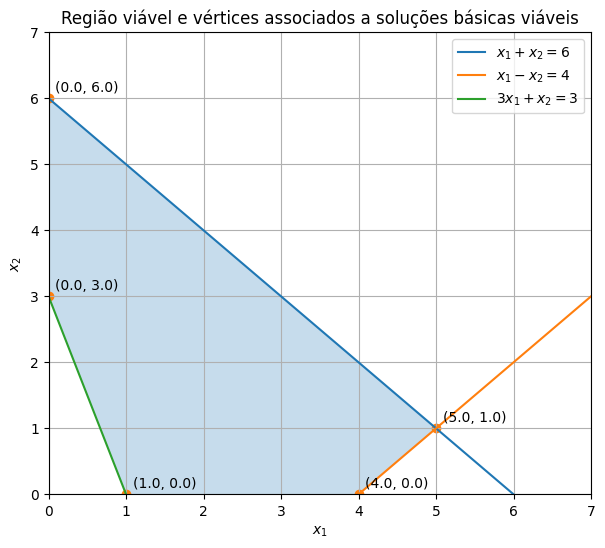

In [4]:
# Visualização no plano (x1, x2)
# Restrições:
# x1 + x2 <= 6
# x1 - x2 <= 4
# 3x1 + x2 >= 3
# x1, x2 >= 0

fig, ax = plt.subplots(figsize=(7, 6))

# Pontos extremos calculados a partir das bases viáveis
pts = vertices[["x1", "x2"]].drop_duplicates().to_numpy()

# Ordenação angular para formar o polígono
center = pts.mean(axis=0)
angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
pts_sorted = pts[np.argsort(angles)]

ax.fill(pts_sorted[:, 0], pts_sorted[:, 1], alpha=0.25)
ax.scatter(pts[:, 0], pts[:, 1])

for i, (x1, x2) in enumerate(pts):
    ax.annotate(f"({x1:.1f}, {x2:.1f})", (x1, x2), textcoords="offset points", xytext=(5, 5))

x = np.linspace(0, 7, 200)
ax.plot(x, 6 - x, label=r"$x_1+x_2=6$")
ax.plot(x, x - 4, label=r"$x_1-x_2=4$")
ax.plot(x, 3 - 3*x, label=r"$3x_1+x_2=3$")

ax.set_xlim(0, 7)
ax.set_ylim(0, 7)
ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_title("Região viável e vértices associados a soluções básicas viáveis")
ax.legend()
ax.grid(True)
plt.show()

## 3. Exemplo manual do Método Simplex

Agora resolvemos manualmente um exemplo do tipo apresentado no livro.

Problema:

\[
\min f(x_1,x_2)=-2x_1-x_2
\]

sujeito a:

\[
x_1+x_2\leq 4,
\]

\[
x_1\leq 3,
\]

\[
x_2\leq \frac{7}{2},
\]

\[
x_1,x_2\geq 0.
\]

Introduzindo variáveis de folga:

\[
x_1+x_2+x_3=4,
\]

\[
x_1+x_4=3,
\]

\[
x_2+x_5=\frac{7}{2}.
\]

Assim:

\[
A=\begin{bmatrix}
1&1&1&0&0\\
1&0&0&1&0\\
0&1&0&0&1
\end{bmatrix},
\quad
b=\begin{bmatrix}4\\3\\7/2\end{bmatrix},
\quad
c=\begin{bmatrix}-2\\-1\\0\\0\\0\end{bmatrix}.
\]

### Iteração 0

Base inicial pelas folgas:

\[
B=(x_3,x_4,x_5).
\]

Logo:

\[
B=I,
\quad
x_B=B^{-1}b=b=\begin{bmatrix}4\\3\\7/2\end{bmatrix}.
\]

Portanto:

\[
x=(0,0,4,3,7/2),
\quad
f(x)=0.
\]

Como \(c_B=(0,0,0)^T\), temos:

\[
\lambda=(0,0,0)^T.
\]

Os custos relativos das variáveis não básicas são:

\[
\bar{c}_1=c_1-\lambda^Ta_1=-2,
\]

\[
\bar{c}_2=c_2-\lambda^Ta_2=-1.
\]

Como o problema é de minimização e há custos relativos negativos, a solução atual não é ótima.

Pela regra de Dantzig, escolhemos o custo mais negativo. Portanto:

\[
x_1 \text{ entra na base.}
\]

A direção simplex é:

\[
y=B^{-1}a_1=a_1=\begin{bmatrix}1\\1\\0\end{bmatrix}.
\]

O tamanho do passo é:

\[
\varepsilon=\min\left\{\frac{4}{1},\frac{3}{1}\right\}=3.
\]

Logo, \(x_4\) sai da base.

Nova solução:

\[
x_1=3,
\quad
x_4=0,
\]

\[
x=(3,0,1,0,7/2),
\quad
f(x)=-6.
\]

### Iteração 1

Nova base:

\[
B=(x_3,x_1,x_5).
\]

As variáveis básicas são:

\[
x_B=(x_3,x_1,x_5)^T=(1,3,7/2)^T.
\]

O valor da função objetivo é:

\[
f(x)=-2(3)-0=-6.
\]

Calculando o multiplicador simplex:

\[
B^T\lambda=c_B.
\]

Para essa base, obtemos:

\[
\lambda=(0,-2,0)^T.
\]

As variáveis não básicas são \(x_4\) e \(x_2\). Seus custos relativos são:

\[
\bar{c}_4=2,
\]

\[
\bar{c}_2=-1.
\]

Como \(\bar{c}_2<0\), a solução ainda não é ótima. Assim:

\[
x_2 \text{ entra na base.}
\]

A direção simplex é:

\[
y=B^{-1}a_2=\begin{bmatrix}1\\0\\1\end{bmatrix}.
\]

O passo é:

\[
\varepsilon=\min\left\{\frac{1}{1},\frac{7/2}{1}\right\}=1.
\]

Logo, \(x_3\) sai da base.

Nova solução:

\[
x=(3,1,0,0,5/2),
\]

\[
f(x)=-2(3)-1=-7.
\]

### Iteração 2: teste de otimalidade

Na nova base, os custos relativos das variáveis não básicas são não negativos. Logo, a solução é ótima.

Portanto:

\[
\boxed{x_1^*=3,\quad x_2^*=1}
\]

\[
\boxed{f(x^*)=-7}.
\]

## 4. Implementação do Método Simplex em Python

Segue a implementação do Simplex para problemas na forma:

\[
\min c^T x
\]

sujeito a:

\[
Ax=b,
\qquad
x\geq 0.
\]

A entrada exige uma base inicial viável, dada pelos índices das variáveis básicas.

Essa escolha é coerente com a leitura via Álgebra Linear: o algoritmo trabalha explicitamente com a matriz básica \(B\), resolve sistemas lineares com \(B\), calcula custos relativos e troca colunas da base.

In [5]:
from dataclasses import dataclass

@dataclass
class SimplexResult:
    status: str
    x: np.ndarray | None
    objective: float | None
    basis: list[int] | None
    iterations: pd.DataFrame


def simplex_revisado_min(A, b, c, base_inicial, var_names=None, tol=1e-9, max_iter=100):
    """
    Método Simplex revisado para problemas na forma:

        min c^T x
        s.a. A x = b
             x >= 0

    Parâmetros
    ----------
    A : array (m x n)
        Matriz de restrições.
    b : array (m,)
        Vetor do lado direito.
    c : array (n,)
        Vetor de custos.
    base_inicial : lista de inteiros
        Índices das variáveis básicas iniciais. Usa indexação Python, iniciando em 0.
    var_names : lista de strings, opcional
        Nomes das variáveis.
    tol : float
        Tolerância numérica.
    max_iter : int
        Número máximo de iterações.

    Retorna
    -------
    SimplexResult
        Objeto com status, solução, valor objetivo, base final e histórico de iterações.
    """

    A = np.array(A, dtype=float)
    b = np.array(b, dtype=float)
    c = np.array(c, dtype=float)

    m, n = A.shape

    if len(base_inicial) != m:
        raise ValueError("A base inicial deve ter exatamente m índices.")

    if var_names is None:
        var_names = [f"x{j+1}" for j in range(n)]

    base = list(base_inicial)
    historico = []

    for it in range(max_iter):
        N = [j for j in range(n) if j not in base]
        B = A[:, base]

        if np.linalg.matrix_rank(B, tol=tol) < m:
            raise ValueError("A matriz básica não é inversível.")

        # Solução básica
        xB = np.linalg.solve(B, b)
        x = np.zeros(n)
        x[base] = xB

        if np.any(xB < -tol):
            return SimplexResult(
                status="base inicial/interna inviável",
                x=x,
                objective=float(c @ x),
                basis=base,
                iterations=pd.DataFrame(historico)
            )

        # Multiplicador simplex: B^T lambda = c_B
        cB = c[base]
        lam = np.linalg.solve(B.T, cB)

        # Custos relativos das não básicas
        custos_relativos = {j: c[j] - lam @ A[:, j] for j in N}

        # Seleção da variável que entra: menor custo relativo
        j_entra = min(custos_relativos, key=custos_relativos.get)
        menor_custo = custos_relativos[j_entra]

        objetivo = float(c @ x)

        # Registro antes de testar otimalidade
        registro = {
            "iteracao": it,
            "base": tuple(var_names[j] for j in base),
            "nao_basicas": tuple(var_names[j] for j in N),
            "x": np.round(x, 8),
            "f": objetivo,
            "lambda": np.round(lam, 8),
            "custos_relativos": {var_names[j]: round(float(v), 8) for j, v in custos_relativos.items()},
            "entra": None,
            "sai": None,
            "passo": None,
            "status_iteracao": None
        }

        # Critério de otimalidade para minimização
        if menor_custo >= -tol:
            registro["status_iteracao"] = "ótima"
            historico.append(registro)
            return SimplexResult(
                status="ótima",
                x=x,
                objective=objetivo,
                basis=base,
                iterations=pd.DataFrame(historico)
            )

        # Direção simplex
        y = np.linalg.solve(B, A[:, j_entra])

        # Teste de ilimitabilidade
        if np.all(y <= tol):
            registro["entra"] = var_names[j_entra]
            registro["status_iteracao"] = "ilimitada"
            historico.append(registro)
            return SimplexResult(
                status="ilimitada",
                x=None,
                objective=None,
                basis=base,
                iterations=pd.DataFrame(historico)
            )

        # Teste da razão mínima
        razoes = np.array([
            xB[i] / y[i] if y[i] > tol else np.inf
            for i in range(m)
        ])

        pos_sai = int(np.argmin(razoes))
        passo = float(razoes[pos_sai])
        j_sai = base[pos_sai]

        registro["entra"] = var_names[j_entra]
        registro["sai"] = var_names[j_sai]
        registro["passo"] = passo
        registro["status_iteracao"] = "troca de base"
        historico.append(registro)

        # Atualiza a base
        base[pos_sai] = j_entra

    return SimplexResult(
        status="máximo de iterações atingido",
        x=None,
        objective=None,
        basis=base,
        iterations=pd.DataFrame(historico)
    )

## 5. Testando a implementação

### 5.1 Teste 1 — exemplo manual com base inicial de folgas

Usaremos novamente:

\[
\min f=-2x_1-x_2
\]

sujeito a:

\[
x_1+x_2+x_3=4,
\]

\[
x_1+x_4=3,
\]

\[
x_2+x_5=7/2.
\]

Base inicial:

\[
B=(x_3,x_4,x_5).
\]

In [6]:
A1 = np.array([
    [1, 1, 1, 0, 0],
    [1, 0, 0, 1, 0],
    [0, 1, 0, 0, 1]
], dtype=float)

b1 = np.array([4, 3, 7/2], dtype=float)
c1 = np.array([-2, -1, 0, 0, 0], dtype=float)
var_names1 = ["x1", "x2", "x3", "x4", "x5"]

# Base inicial: x3, x4, x5 -> índices Python 2, 3, 4
res1 = simplex_revisado_min(A1, b1, c1, base_inicial=[2, 3, 4], var_names=var_names1)

print("Status:", res1.status)
print("Solução:", dict(zip(var_names1, np.round(res1.x, 8))))
print("Valor objetivo:", res1.objective)
print("Base final:", [var_names1[j] for j in res1.basis])

res1.iterations

Status: ótima
Solução: {'x1': np.float64(3.0), 'x2': np.float64(1.0), 'x3': np.float64(0.0), 'x4': np.float64(0.0), 'x5': np.float64(2.5)}
Valor objetivo: -7.0
Base final: ['x2', 'x1', 'x5']


,iteracao,base,nao_basicas,x,f,lambda,custos_relativos,entra,sai,passo,status_iteracao
0,0,"(x3, x4, x5)","(x1, x2)","[0.0, 0.0, 4.0, 3.0, 3.5]",0.0,"[0.0, 0.0, 0.0]","{'x1': -2.0, 'x2': -1.0}",x1,x4,3.0,troca de base
1,1,"(x3, x1, x5)","(x2, x4)","[3.0, 0.0, 1.0, 0.0, 3.5]",-6.0,"[0.0, -2.0, 0.0]","{'x2': -1.0, 'x4': 2.0}",x2,x3,1.0,troca de base
2,2,"(x2, x1, x5)","(x3, x4)","[3.0, 1.0, 0.0, 0.0, 2.5]",-7.0,"[-1.0, -1.0, 0.0]","{'x3': 1.0, 'x4': 1.0}",NaN,NaN,NaN,ótima


O resultado confirma a resolução manual:

\[
x_1^*=3,
\quad
x_2^*=1,
\quad
f(x^*)=-7.
\]

### 5.2 Teste 2 — mesmo problema, outra base viável inicial

Agora usamos o mesmo problema, mas com outra base inicial:

\[
B=(x_1,x_2,x_4).
\]

Essa base também é viável, mas não é ótima. O algoritmo deve trocar uma variável da base e chegar ao mesmo ótimo.

In [7]:
# Base inicial: x1, x2, x4 -> índices Python 0, 1, 3
res2 = simplex_revisado_min(A1, b1, c1, base_inicial=[0, 1, 3], var_names=var_names1)

print("Status:", res2.status)
print("Solução:", dict(zip(var_names1, np.round(res2.x, 8))))
print("Valor objetivo:", res2.objective)
print("Base final:", [var_names1[j] for j in res2.basis])

res2.iterations

Status: ótima
Solução: {'x1': np.float64(3.0), 'x2': np.float64(1.0), 'x3': np.float64(0.0), 'x4': np.float64(0.0), 'x5': np.float64(2.5)}
Valor objetivo: -7.0
Base final: ['x1', 'x2', 'x5']


,iteracao,base,nao_basicas,x,f,lambda,custos_relativos,entra,sai,passo,status_iteracao
0,0,"(x1, x2, x4)","(x3, x5)","[0.5, 3.5, 0.0, 2.5, 0.0]",-4.5,"[-2.0, -0.0, 1.0]","{'x3': 2.0, 'x5': -1.0}",x5,x4,2.5,troca de base
1,1,"(x1, x2, x5)","(x3, x4)","[3.0, 1.0, 0.0, 0.0, 2.5]",-7.0,"[-1.0, -1.0, 0.0]","{'x3': 1.0, 'x4': 1.0}",NaN,NaN,NaN,ótima


A solução ótima é a mesma. A diferença é a trajetória: o Simplex pode partir de bases viáveis diferentes e, ainda assim, atingir o mesmo vértice ótimo.

### 5.3 Teste 3 — problema de maximização convertido para minimização

Considere:

\[
\max z=3x_1+2x_2
\]

sujeito a:

\[
x_1+x_2\leq 4,
\]

\[
x_1\leq 2,
\]

\[
x_2\leq 3,
\]

\[
x_1,x_2\geq 0.
\]

Para usar a função de minimização, fazemos:

\[
\max z=3x_1+2x_2
\quad\Longleftrightarrow\quad
\min f=-3x_1-2x_2.
\]

Depois introduzimos variáveis de folga.

In [8]:
def resolver_max_leq(c_max, A_leq, b_leq, tol=1e-9):
    """
    Resolve max c^T x sujeito a A x <= b, x >= 0,
    convertendo para min -c^T x com variáveis de folga.
    """
    A_leq = np.array(A_leq, dtype=float)
    b_leq = np.array(b_leq, dtype=float)
    c_max = np.array(c_max, dtype=float)

    m, n = A_leq.shape
    A_std = np.hstack([A_leq, np.eye(m)])
    c_min = np.concatenate([-c_max, np.zeros(m)])
    base_inicial = list(range(n, n + m))
    var_names = [f"x{j+1}" for j in range(n)] + [f"s{j+1}" for j in range(m)]

    res = simplex_revisado_min(A_std, b_leq, c_min, base_inicial, var_names=var_names, tol=tol)

    if res.status == "ótima":
        x_original = res.x[:n]
        z_max = c_max @ x_original
        return res, x_original, z_max, var_names
    return res, None, None, var_names

c_max = np.array([3, 2], dtype=float)
A_leq = np.array([
    [1, 1],
    [1, 0],
    [0, 1]
], dtype=float)
b_leq = np.array([4, 2, 3], dtype=float)

res3, x3, z3, names3 = resolver_max_leq(c_max, A_leq, b_leq)

print("Status:", res3.status)
print("Solução original:", x3)
print("Valor máximo:", z3)
print("Solução completa:", dict(zip(names3, np.round(res3.x, 8))))

res3.iterations

Status: ótima
Solução original: [2. 2.]
Valor máximo: 10.0
Solução completa: {'x1': np.float64(2.0), 'x2': np.float64(2.0), 's1': np.float64(0.0), 's2': np.float64(0.0), 's3': np.float64(1.0)}


,iteracao,base,nao_basicas,x,f,lambda,custos_relativos,entra,sai,passo,status_iteracao
0,0,"(s1, s2, s3)","(x1, x2)","[0.0, 0.0, 4.0, 2.0, 3.0]",0.0,"[0.0, 0.0, 0.0]","{'x1': -3.0, 'x2': -2.0}",x1,s2,2.0,troca de base
1,1,"(s1, x1, s3)","(x2, s2)","[2.0, 0.0, 2.0, 0.0, 3.0]",-6.0,"[0.0, -3.0, 0.0]","{'x2': -2.0, 's2': 3.0}",x2,s1,2.0,troca de base
2,2,"(x2, x1, s3)","(s1, s2)","[2.0, 2.0, 0.0, 0.0, 1.0]",-10.0,"[-2.0, -1.0, 0.0]","{'s1': 2.0, 's2': 1.0}",NaN,NaN,NaN,ótima


A solução encontrada é:

\[
x_1^*=2,
\quad
x_2^*=2,
\quad
z_{\max}=10.
\]

### 5.4 Teste 4 — problema ilimitado

Agora testamos se a implementação detecta um caso ilimitado.

Considere:

\[
\min f=-x_1
\]

sujeito a:

\[
x_1-x_2=1,
\]

\[
x_1,x_2\geq 0.
\]

Como \(x_1=1+x_2\), podemos fazer \(x_2\to\infty\). Então:

\[
f=-(1+x_2)\to -\infty.
\]

Logo, o problema é ilimitado para minimização.

In [9]:
A_unb = np.array([[1, -1]], dtype=float)
b_unb = np.array([1], dtype=float)
c_unb = np.array([-1, 0], dtype=float)

res4 = simplex_revisado_min(
    A_unb,
    b_unb,
    c_unb,
    base_inicial=[0],
    var_names=["x1", "x2"]
)

print("Status:", res4.status)
res4.iterations

Status: ilimitada


,iteracao,base,nao_basicas,x,f,lambda,custos_relativos,entra,sai,passo,status_iteracao
0,0,"(x1,)","(x2,)","[1.0, 0.0]",-1.0,[-1.0],{'x2': -1.0},x2,None,None,ilimitada


O algoritmo identifica que a direção de melhoria não possui limite superior viável. Portanto, o problema é classificado como ilimitado.

## Conclusão

O Método Simplex pode ser entendido como uma aplicação direta de conceitos de Álgebra Linear, sendo interpretado como um algoritmo de troca de bases aplicado a problemas de progração linear. Na forma padrão,

\[
Ax = b, \qquad x \geq 0,
\]

cada base é formada por um conjunto de colunas linearmente independentes da matriz \(A\). A partir dela, obtém-se uma **solução básica**. Quando essa solução satisfaz a condição de não negatividade, ela é uma **solução basica viaÀável**.

Geometricamente, as soluções básicas viáveis correspondem aos **vértices da região viável**. Assim, o Simplex percorre esses vértices por meio de trocas entre variáveis básicas e não básicas, até encontrar a solução que otimiza a função objetivo.

Em cada iteração, os **custos relativos** indicam se ainda é possível melhorar a solução, enquanto a **direção simplex** e o **teste da razão mínima** determinam qual variável deve sair da base.

Em síntese:

\[
\boxed{\text{Simplex = busca pelo ótimo por trocas sucessivas de bases viáveis.}}
\]